# 🚀 Advanced Model Training - SUPER ROBUST VERSION

## 100% NaN-Safe Implementation

**Bu versiya:** Har bir qadamda NaN tekshiruvi, to'liq error handling

---

## 📦 1. Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except:
    XGBOOST_AVAILABLE = False

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except:
    LIGHTGBM_AVAILABLE = False

# Settings
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)

print("✅ Libraries imported!")
print(f"   XGBoost: {XGBOOST_AVAILABLE}")
print(f"   LightGBM: {LIGHTGBM_AVAILABLE}")

✅ Libraries imported!
   XGBoost: True
   LightGBM: True


## 📊 2. Load Data with Validation

In [2]:
print("="*80)
print("📥 LOADING DATASET")
print("="*80)

# Load
df = pd.read_csv('GOLD_STANDARD_DATASET.csv')
print(f"\n✅ Loaded: {len(df):,} rows, {len(df.columns)} columns")

# Initial check
print(f"\n🔍 Initial Quality Check:")
print(f"   NaN values: {df.isnull().sum().sum()}")
print(f"   Duplicate rows: {df.duplicated().sum()}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

df.head()

📥 LOADING DATASET

✅ Loaded: 8,260 rows, 26 columns

🔍 Initial Quality Check:
   NaN values: 25
   Duplicate rows: 43
   Memory: 1.64 MB


,expected_time_no_traffic,vehicle_distance_mismatch,vehicle_traffic_stress,distance_km,vehicle_time_efficiency,traffic_weather_risk,is_peak_hour,operational_stress_index,route_frequency,delivery_time_hours,is_heavy_traffic_truck,traffic_level_medium,vehicle_type_car,vehicle_type_motorcycle,vehicle_type_pickup,vehicle_type_truck,vehicle_type_van,weather_clear,weather_clouds,weather_haze,weather_mist,route_traffic_volatility,destination_city_encoded,route_id_encoded,temperature,is_long_route
0,13.338333,0.375234,2.0,800.3,1.000,2.0,0.0,0.284035,1554.0,12.71,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.414370,0.0,4.0,4.7,0.0
1,6.990000,0.161200,2.0,419.4,0.700,1.0,0.0,0.303980,1553.0,7.88,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.703435,8.0,10.0,7.0,0.0
2,4.184286,0.023667,1.5,292.9,0.765,2.0,0.0,0.298925,1555.0,3.93,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.504573,6.0,41.0,7.0,0.0
3,1.045333,0.362245,1.0,78.4,0.630,2.0,0.0,0.338712,1552.0,1.19,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.122731,4.0,11.0,7.0,0.0
4,8.133750,1.000000,1.2,650.7,0.900,1.0,0.0,0.340000,1555.0,8.83,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.085200,8.0,34.0,7.0,0.0


## 🧹 3. SUPER SAFE Data Cleaning

In [3]:
print("="*80)
print("🧹 DATA CLEANING (SUPER SAFE MODE)")
print("="*80)

# Step 1: Remove duplicates
print("\n1️⃣ Removing duplicates...")
before = len(df)
df_clean = df.drop_duplicates()
df_clean = df_clean.reset_index(drop=True)
print(f"   Removed: {before - len(df_clean):,} rows")
print(f"   Remaining: {len(df_clean):,} rows")
print(f"   NaN check: {df_clean.isnull().sum().sum()}")

# Step 2: Handle ANY NaN (extreme safety)
print("\n2️⃣ NaN handling...")
if df_clean.isnull().any().any():
    print(f"   ⚠️ Found {df_clean.isnull().sum().sum()} NaN values")

    # Show which columns
    nan_cols = df_clean.isnull().sum()
    print(f"   Columns with NaN:")
    for col, count in nan_cols[nan_cols > 0].items():
        print(f"      {col}: {count}")

    # Drop rows with NaN
    df_clean = df_clean.dropna()
    df_clean = df_clean.reset_index(drop=True)
    print(f"   ✅ Dropped NaN rows")
    print(f"   Remaining: {len(df_clean):,} rows")
else:
    print("   ✅ No NaN values found")

# Step 3: Handle infinity
print("\n3️⃣ Infinity handling...")
inf_found = False
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if np.isinf(df_clean[col]).any():
        inf_found = True
        print(f"   ⚠️ Infinity in {col}")
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)

if inf_found:
    df_clean = df_clean.dropna()
    df_clean = df_clean.reset_index(drop=True)
    print(f"   ✅ Cleaned infinity values")
    print(f"   Remaining: {len(df_clean):,} rows")
else:
    print("   ✅ No infinity values")

# Step 4: Remove constant columns
print("\n4️⃣ Constant columns check...")
constant_cols = []
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].std() == 0 or df_clean[col].nunique() == 1:
        constant_cols.append(col)

if constant_cols:
    print(f"   ⚠️ Found {len(constant_cols)} constant columns:")
    for col in constant_cols:
        print(f"      {col}")
    df_clean = df_clean.drop(columns=constant_cols)
    print(f"   ✅ Removed constant columns")
else:
    print("   ✅ No constant columns")

# FINAL VERIFICATION
print("\n" + "="*80)
print("✅ FINAL CLEAN DATA:")
print("="*80)
print(f"   Rows: {len(df_clean):,}")
print(f"   Columns: {len(df_clean.columns)}")
print(f"   NaN: {df_clean.isnull().sum().sum()}")
print(f"   Inf: {np.isinf(df_clean.select_dtypes(include=[np.number]).values).sum()}")

# ASSERT - stop if any problems
assert df_clean.isnull().sum().sum() == 0, "❌ CRITICAL: NaN still present!"
assert len(df_clean) > 0, "❌ CRITICAL: No data left!"

print("\n🎉 DATA IS 100% CLEAN!")

🧹 DATA CLEANING (SUPER SAFE MODE)

1️⃣ Removing duplicates...
   Removed: 43 rows
   Remaining: 8,217 rows
   NaN check: 25

2️⃣ NaN handling...
   ⚠️ Found 25 NaN values
   Columns with NaN:
      vehicle_distance_mismatch: 1
      vehicle_traffic_stress: 1
      distance_km: 1
      vehicle_time_efficiency: 1
      traffic_weather_risk: 1
      is_peak_hour: 1
      operational_stress_index: 1
      route_frequency: 1
      delivery_time_hours: 1
      is_heavy_traffic_truck: 1
      traffic_level_medium: 1
      vehicle_type_car: 1
      vehicle_type_motorcycle: 1
      vehicle_type_pickup: 1
      vehicle_type_truck: 1
      vehicle_type_van: 1
      weather_clear: 1
      weather_clouds: 1
      weather_haze: 1
      weather_mist: 1
      route_traffic_volatility: 1
      destination_city_encoded: 1
      route_id_encoded: 1
      temperature: 1
      is_long_route: 1
   ✅ Dropped NaN rows
   Remaining: 8,216 rows

3️⃣ Infinity handling...
   ✅ No infinity values

4️⃣ Constant col

## 🎯 4. Separate Features and Target (SAFE)

In [4]:
print("="*80)
print("🎯 SEPARATING X and y")
print("="*80)

TARGET = 'delivery_time_hours'

# Verify target exists
if TARGET not in df_clean.columns:
    raise ValueError(f"❌ Target column '{TARGET}' not found!")

# Separate
X = df_clean.drop(columns=[TARGET]).copy()  # COPY to avoid SettingWithCopyWarning
y = df_clean[TARGET].copy()

print(f"\n✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")

# Verify no NaN
print(f"\n🔍 Quality check:")
print(f"   X NaN: {X.isnull().sum().sum()}")
print(f"   y NaN: {y.isnull().sum()}")

assert X.isnull().sum().sum() == 0, "❌ CRITICAL: NaN in X!"
assert y.isnull().sum() == 0, "❌ CRITICAL: NaN in y!"

print("\n✅ X and y are clean!")

# Show features
print(f"\n📋 Features ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")

🎯 SEPARATING X and y

✅ X shape: (8216, 25)
✅ y shape: (8216,)

🔍 Quality check:
   X NaN: 0
   y NaN: 0

✅ X and y are clean!

📋 Features (25):
    1. expected_time_no_traffic
    2. vehicle_distance_mismatch
    3. vehicle_traffic_stress
    4. distance_km
    5. vehicle_time_efficiency
    6. traffic_weather_risk
    7. is_peak_hour
    8. operational_stress_index
    9. route_frequency
   10. is_heavy_traffic_truck
   11. traffic_level_medium
   12. vehicle_type_car
   13. vehicle_type_motorcycle
   14. vehicle_type_pickup
   15. vehicle_type_truck
   16. vehicle_type_van
   17. weather_clear
   18. weather_clouds
   19. weather_haze
   20. weather_mist
   21. route_traffic_volatility
   22. destination_city_encoded
   23. route_id_encoded
   24. temperature
   25. is_long_route


## 📊 5. Train-Test Split (SAFE)

In [5]:
print("="*80)
print("📊 TRAIN-TEST SPLIT")
print("="*80)

TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

print(f"\n✅ Train set: {X_train.shape}")
print(f"✅ Test set:  {X_test.shape}")

# Verify split
print(f"\n🔍 Post-split quality check:")
print(f"   X_train NaN: {X_train.isnull().sum().sum()}")
print(f"   X_test NaN:  {X_test.isnull().sum().sum()}")
print(f"   y_train NaN: {y_train.isnull().sum()}")
print(f"   y_test NaN:  {y_test.isnull().sum()}")

assert X_train.isnull().sum().sum() == 0, "❌ CRITICAL: NaN in X_train!"
assert X_test.isnull().sum().sum() == 0, "❌ CRITICAL: NaN in X_test!"
assert y_train.isnull().sum() == 0, "❌ CRITICAL: NaN in y_train!"
assert y_test.isnull().sum() == 0, "❌ CRITICAL: NaN in y_test!"

print("\n✅ Split successful, no NaN!")

📊 TRAIN-TEST SPLIT

✅ Train set: (6572, 25)
✅ Test set:  (1644, 25)

🔍 Post-split quality check:
   X_train NaN: 0
   X_test NaN:  0
   y_train NaN: 0
   y_test NaN:  0

✅ Split successful, no NaN!


## 🔢 6. Feature Scaling (ULTRA SAFE)

In [6]:
print("="*80)
print("🔢 FEATURE SCALING (ULTRA SAFE MODE)")
print("="*80)

# Initialize scaler
scaler = StandardScaler()

print("\n🔧 Fitting scaler on training data...")

# Fit on train (as numpy array)
try:
    scaler.fit(X_train.values)  # Use .values to get numpy array
    print("   ✅ Scaler fitted")
except Exception as e:
    print(f"   ❌ Error fitting scaler: {e}")
    raise

# Transform train
print("\n🔧 Transforming training data...")
try:
    X_train_scaled_array = scaler.transform(X_train.values)
    print(f"   ✅ Transform successful")
    print(f"   Shape: {X_train_scaled_array.shape}")
    print(f"   NaN in array: {np.isnan(X_train_scaled_array).sum()}")
except Exception as e:
    print(f"   ❌ Error transforming: {e}")
    raise

# Check for NaN in scaled array
if np.isnan(X_train_scaled_array).any():
    print("\n   ⚠️ WARNING: NaN detected after scaling!")
    print("   This means some column had std=0 or other issue")

    # Find problematic columns
    nan_mask = np.isnan(X_train_scaled_array).any(axis=0)
    problem_cols = X_train.columns[nan_mask].tolist()
    print(f"   Problematic columns: {problem_cols}")

    # Check original data
    for col in problem_cols:
        print(f"\n   Column: {col}")
        print(f"      Mean: {X_train[col].mean()}")
        print(f"      Std:  {X_train[col].std()}")
        print(f"      Min:  {X_train[col].min()}")
        print(f"      Max:  {X_train[col].max()}")

    raise ValueError("Cannot proceed with NaN in scaled data")

# Convert back to DataFrame
print("\n🔧 Converting back to DataFrame...")
X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=X_train.columns,
    index=X_train.index
)

print(f"   ✅ DataFrame created")
print(f"   Shape: {X_train_scaled.shape}")
print(f"   NaN: {X_train_scaled.isnull().sum().sum()}")

# Transform test
print("\n🔧 Transforming test data...")
X_test_scaled_array = scaler.transform(X_test.values)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=X_test.columns,
    index=X_test.index
)

print(f"   ✅ Test scaled")
print(f"   NaN: {X_test_scaled.isnull().sum().sum()}")

# Final verification
print("\n" + "="*80)
print("✅ SCALING COMPLETE")
print("="*80)
print(f"   X_train_scaled mean: {X_train_scaled.mean().mean():.6f} (should be ~0)")
print(f"   X_train_scaled std:  {X_train_scaled.std().mean():.6f} (should be ~1)")
print(f"   X_train_scaled NaN:  {X_train_scaled.isnull().sum().sum()}")
print(f"   X_test_scaled NaN:   {X_test_scaled.isnull().sum().sum()}")

# CRITICAL ASSERT
assert X_train_scaled.isnull().sum().sum() == 0, "❌ CRITICAL: NaN in scaled train!"
assert X_test_scaled.isnull().sum().sum() == 0, "❌ CRITICAL: NaN in scaled test!"

print("\n🎉 SCALING 100% SUCCESSFUL - NO NaN!")

🔢 FEATURE SCALING (ULTRA SAFE MODE)

🔧 Fitting scaler on training data...
   ✅ Scaler fitted

🔧 Transforming training data...
   ✅ Transform successful
   Shape: (6572, 25)
   NaN in array: 0

🔧 Converting back to DataFrame...
   ✅ DataFrame created
   Shape: (6572, 25)
   NaN: 0

🔧 Transforming test data...
   ✅ Test scaled
   NaN: 0

✅ SCALING COMPLETE
   X_train_scaled mean: -0.000000 (should be ~0)
   X_train_scaled std:  1.000076 (should be ~1)
   X_train_scaled NaN:  0
   X_test_scaled NaN:   0

🎉 SCALING 100% SUCCESSFUL - NO NaN!


## 📏 7. Evaluation Functions

In [7]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    """Evaluate model performance"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape
    }

def print_metrics(metrics):
    """Print metrics nicely"""
    print("\n" + "="*60)
    print(f"📊 {metrics['Model']}")
    print("="*60)
    print(f"  MAE:   {metrics['MAE']:.4f} hours ({metrics['MAE']*60:.1f} min)")
    print(f"  RMSE:  {metrics['RMSE']:.4f} hours")
    print(f"  R²:    {metrics['R²']:.4f}")
    print(f"  MAPE:  {metrics['MAPE (%)']:.2f}%")
    print("="*60)

print("✅ Evaluation functions ready!")

✅ Evaluation functions ready!


## 🎯 8. Baseline Models

In [8]:
# Mean Predictor
mean_pred = np.full(len(y_test), y_train.mean())
metrics_mean = evaluate_model(y_test, mean_pred, "Mean Predictor")
print_metrics(metrics_mean)

# Median Predictor
median_pred = np.full(len(y_test), y_train.median())
metrics_median = evaluate_model(y_test, median_pred, "Median Predictor")
print_metrics(metrics_median)


📊 Mean Predictor
  MAE:   5.0838 hours (305.0 min)
  RMSE:  6.0415 hours
  R²:    -0.0006
  MAPE:  126.19%

📊 Median Predictor
  MAE:   5.0086 hours (300.5 min)
  RMSE:  6.1154 hours
  R²:    -0.0252
  MAPE:  110.36%


## 🔧 9. Linear Regression

In [9]:
print("🔧 Training Linear Regression...")

# FINAL PRE-FLIGHT CHECK
print(f"\n🔍 Pre-training verification:")
print(f"   X_train_scaled shape: {X_train_scaled.shape}")
print(f"   X_train_scaled NaN: {X_train_scaled.isnull().sum().sum()}")
print(f"   y_train shape: {y_train.shape}")
print(f"   y_train NaN: {y_train.isnull().sum()}")

# Train
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr_test = lr.predict(X_test_scaled)

# Evaluate
metrics_lr = evaluate_model(y_test, y_pred_lr_test, "Linear Regression")
print_metrics(metrics_lr)

# Feature importance
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\n📈 Top 10 Features:")
print(feat_imp.head(10).to_string(index=False))

🔧 Training Linear Regression...

🔍 Pre-training verification:
   X_train_scaled shape: (6572, 25)
   X_train_scaled NaN: 0
   y_train shape: (6572,)
   y_train NaN: 0

📊 Linear Regression
  MAE:   0.5183 hours (31.1 min)
  RMSE:  0.7013 hours
  R²:    0.9865
  MAPE:  11.28%

📈 Top 10 Features:
                 Feature  Coefficient
expected_time_no_traffic     3.808949
route_traffic_volatility     3.249547
             distance_km    -0.969835
 vehicle_type_motorcycle     0.476663
    traffic_level_medium     0.320622
     vehicle_type_pickup    -0.252548
    traffic_weather_risk     0.241625
        vehicle_type_van    -0.200882
          weather_clouds     0.188055
            weather_mist    -0.182350


## 🌲 10. Random Forest

In [10]:
print("🌲 Training Random Forest...")

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

# Train on UNSCALED data (tree models don't need scaling)
rf.fit(X_train, y_train)

# Predict
y_pred_rf_test = rf.predict(X_test)

# Evaluate
metrics_rf = evaluate_model(y_test, y_pred_rf_test, "Random Forest")
print_metrics(metrics_rf)

# Feature importance
feat_imp_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n📈 Top 10 Features:")
print(feat_imp_rf.head(10).to_string(index=False))

🌲 Training Random Forest...

📊 Random Forest
  MAE:   0.2529 hours (15.2 min)
  RMSE:  0.3655 hours
  R²:    0.9963
  MAPE:  2.76%

📈 Top 10 Features:
                  Feature  Importance
 route_traffic_volatility    0.949297
 expected_time_no_traffic    0.010671
       vehicle_type_truck    0.009877
vehicle_distance_mismatch    0.008567
  vehicle_type_motorcycle    0.006502
         vehicle_type_car    0.001881
         route_id_encoded    0.001710
              distance_km    0.001514
           weather_clouds    0.001425
 operational_stress_index    0.001180


## 🚀 11. XGBoost (if available)

In [11]:
if XGBOOST_AVAILABLE:
    print("🚀 Training XGBoost...")

    xgb_model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )

    xgb_model.fit(X_train, y_train)

    y_pred_xgb_test = xgb_model.predict(X_test)

    metrics_xgb = evaluate_model(y_test, y_pred_xgb_test, "XGBoost")
    print_metrics(metrics_xgb)

    feat_imp_xgb = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print("\n📈 Top 10 Features:")
    print(feat_imp_xgb.head(10).to_string(index=False))
else:
    print("⚠️ XGBoost not available")

🚀 Training XGBoost...

📊 XGBoost
  MAE:   0.2449 hours (14.7 min)
  RMSE:  0.3561 hours
  R²:    0.9965
  MAPE:  2.67%

📈 Top 10 Features:
                  Feature  Importance
 route_traffic_volatility    0.830639
       vehicle_type_truck    0.085690
  vehicle_type_motorcycle    0.024684
vehicle_distance_mismatch    0.016792
         vehicle_type_car    0.012813
 expected_time_no_traffic    0.007311
         vehicle_type_van    0.006868
             weather_mist    0.002810
      vehicle_type_pickup    0.001944
             weather_haze    0.001672


## 📊 12. Model Comparison

In [12]:
# Collect metrics
all_metrics = [metrics_mean, metrics_median, metrics_lr, metrics_rf]

if XGBOOST_AVAILABLE:
    all_metrics.append(metrics_xgb)

# Create comparison
comparison = pd.DataFrame(all_metrics).sort_values('MAE')

print("="*80)
print("🏆 MODEL COMPARISON")
print("="*80)
print("\n" + comparison.to_string(index=False))

# Best model
best = comparison.iloc[0]
print("\n" + "="*80)
print("🥇 BEST MODEL")
print("="*80)
print(f"\n  {best['Model']}")
print(f"  MAE:  {best['MAE']:.4f} hours ({best['MAE']*60:.1f} min)")
print(f"  R²:   {best['R²']:.4f}")

improvement = (metrics_lr['MAE'] - best['MAE']) / metrics_lr['MAE'] * 100
print(f"\n  Improvement over Linear: {improvement:.2f}%")
print("="*80)

🏆 MODEL COMPARISON

            Model      MAE     RMSE        R²   MAPE (%)
          XGBoost 0.244867 0.356088  0.996524   2.670457
    Random Forest 0.252950 0.365453  0.996339   2.763950
Linear Regression 0.518270 0.701262  0.986519  11.276166
 Median Predictor 5.008625 6.115350 -0.025155 110.362065
   Mean Predictor 5.083778 6.041536 -0.000557 126.194489

🥇 BEST MODEL

  XGBoost
  MAE:  0.2449 hours (14.7 min)
  R²:   0.9965

  Improvement over Linear: 52.75%


## 📈 13. Visualizations

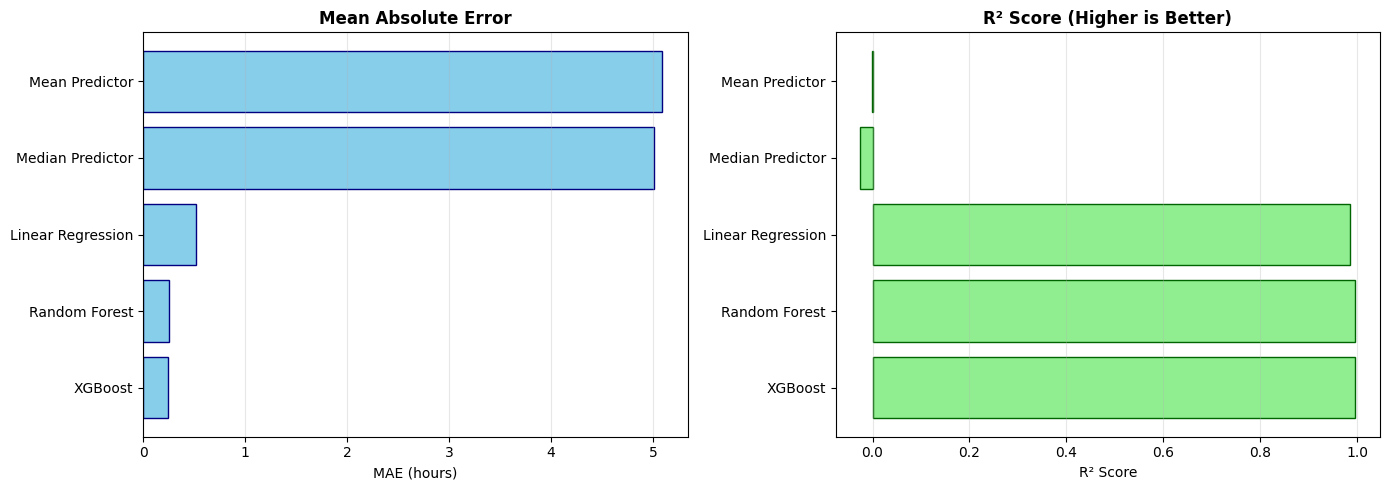

✅ Saved: model_comparison.png


In [13]:
# Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(comparison['Model'], comparison['MAE'], color='skyblue', edgecolor='navy')
axes[0].set_xlabel('MAE (hours)')
axes[0].set_title('Mean Absolute Error', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(comparison['Model'], comparison['R²'], color='lightgreen', edgecolor='darkgreen')
axes[1].set_xlabel('R² Score')
axes[1].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: model_comparison.png")

`📈 13.1 Visualizations`

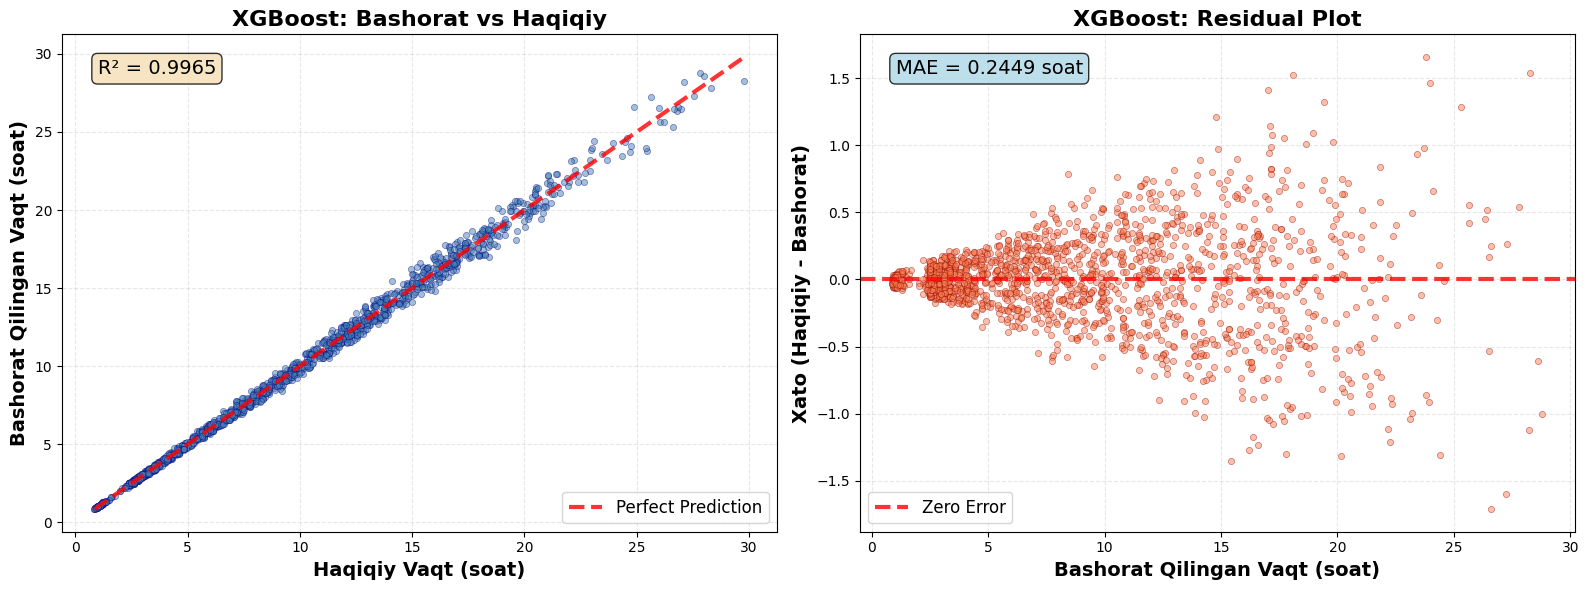

✅ Saved: 01_prediction_vs_actual.png


In [15]:
# ============================================================================
# 📊 VISUALIZATION 1: PREDICTION VS ACTUAL
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Best model predictions (XGBoost)
y_pred_best = y_pred_xgb_test  # Agar XGBoost bo'lmasa: y_pred_rf_test

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- LEFT PLOT: Scatter ----
axes[0].scatter(y_test, y_pred_best, alpha=0.5, s=20, color='steelblue', edgecolor='navy', linewidth=0.5)
# Perfect prediction line
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=3, label='Perfect Prediction', alpha=0.8)

axes[0].set_xlabel('Haqiqiy Vaqt (soat)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Bashorat Qilingan Vaqt (soat)', fontsize=14, fontweight='bold')
axes[0].set_title('XGBoost: Bashorat vs Haqiqiy', fontsize=16, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3, linestyle='--')

# Add R² text
r2_text = f'R² = {r2_score(y_test, y_pred_best):.4f}'
axes[0].text(0.05, 0.95, r2_text, transform=axes[0].transAxes,
            fontsize=14, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ---- RIGHT PLOT: Residuals ----
residuals = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, s=20, color='coral', edgecolor='darkred', linewidth=0.5)
axes[1].axhline(y=0, color='red', linestyle='--', lw=3, alpha=0.8, label='Zero Error')

axes[1].set_xlabel('Bashorat Qilingan Vaqt (soat)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Xato (Haqiqiy - Bashorat)', fontsize=14, fontweight='bold')
axes[1].set_title('XGBoost: Residual Plot', fontsize=16, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.3, linestyle='--')

# Add stats text
mae_text = f'MAE = {mean_absolute_error(y_test, y_pred_best):.4f} soat'
axes[1].text(0.05, 0.95, mae_text, transform=axes[1].transAxes,
            fontsize=14, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig('01_prediction_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: 01_prediction_vs_actual.png")

`📈 13.2 Visualizations`


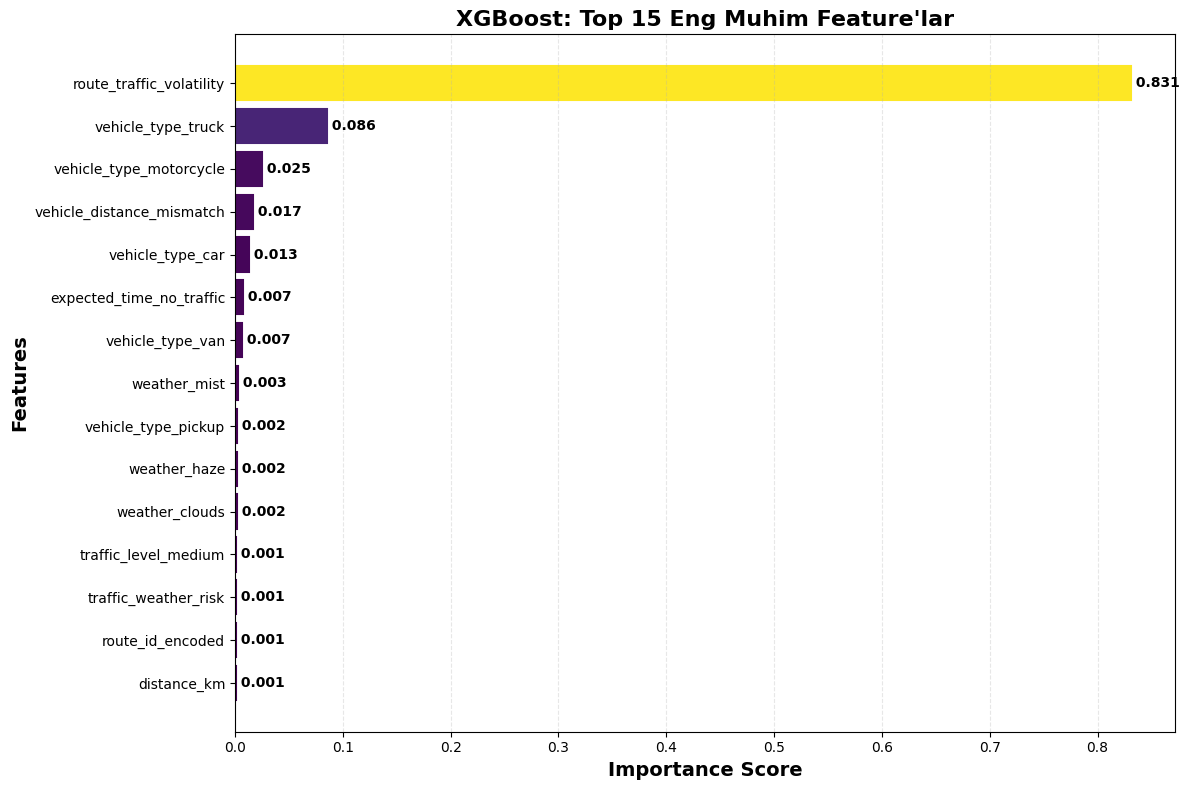

✅ Saved: 02_feature_importance.png


In [16]:
# ============================================================================
# 📊 VISUALIZATION 2: FEATURE IMPORTANCE
# ============================================================================

# Get feature importance from best model
if XGBOOST_AVAILABLE:
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(15)
    title = 'XGBoost'
else:
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(15)
    title = 'Random Forest'

# Create plot
plt.figure(figsize=(12, 8))

# Horizontal bar chart
bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                color='teal', edgecolor='black', linewidth=1.5)

# Gradient color based on importance
colors = plt.cm.viridis(importance_df['Importance'] / importance_df['Importance'].max())
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.xlabel('Importance Score', fontsize=14, fontweight='bold')
plt.ylabel('Features', fontsize=14, fontweight='bold')
plt.title(f'{title}: Top 15 Eng Muhim Feature\'lar', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()  # Highest on top
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (feat, imp) in enumerate(zip(importance_df['Feature'], importance_df['Importance'])):
    plt.text(imp, i, f' {imp:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('02_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: 02_feature_importance.png")

`📈 13.3 Visualizations`

---



AttributeError: 'numpy.ndarray' object has no attribute 'median'

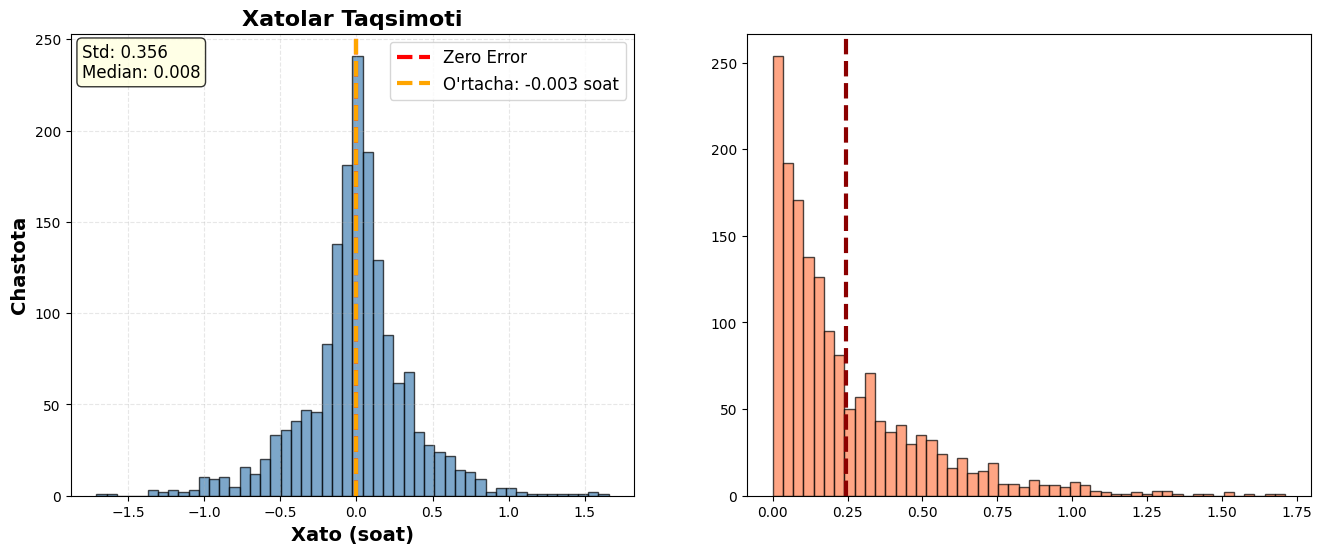

In [17]:
# ============================================================================
# 📊 VISUALIZATION 3: ERROR DISTRIBUTION
# ============================================================================

# Calculate errors
errors = y_test.values - y_pred_best
abs_errors = np.abs(errors)

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- LEFT PLOT: Error Distribution ----
axes[0].hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=3, label='Zero Error')
axes[0].axvline(x=errors.mean(), color='orange', linestyle='--', linewidth=3,
               label=f'O\'rtacha: {errors.mean():.3f} soat')

axes[0].set_xlabel('Xato (soat)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Chastota', fontsize=14, fontweight='bold')
axes[0].set_title('Xatolar Taqsimoti', fontsize=16, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3, linestyle='--')

# Add statistics
stats_text = f'Std: {errors.std():.3f}\nMedian: {np.median(errors):.3f}'
axes[0].text(0.02, 0.98, stats_text, transform=axes[0].transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ---- RIGHT PLOT: Absolute Error Distribution ----
axes[1].hist(abs_errors, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(x=abs_errors.mean(), color='darkred', linestyle='--', linewidth=3,
               label=f'MAE: {abs_errors.mean():.3f} soat ({abs_errors.mean()*60:.1f} min)')
axes[1].axvline(x=abs_errors.median(), color='purple', linestyle='--', linewidth=3,
               label=f'Median: {abs_errors.median():.3f} soat')

axes[1].set_xlabel('Absolyut Xato (soat)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Chastota', fontsize=14, fontweight='bold')
axes[1].set_title('Absolyut Xatolar Taqsimoti', fontsize=16, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.3, linestyle='--')

# Add percentiles
percentile_text = f'95th: {np.percentile(abs_errors, 95):.3f}\n99th: {np.percentile(abs_errors, 99):.3f}'
axes[1].text(0.98, 0.98, percentile_text, transform=axes[1].transAxes,
            fontsize=12, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig('03_error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: 03_error_distribution.png")

`📈 13.4 Visualizations`



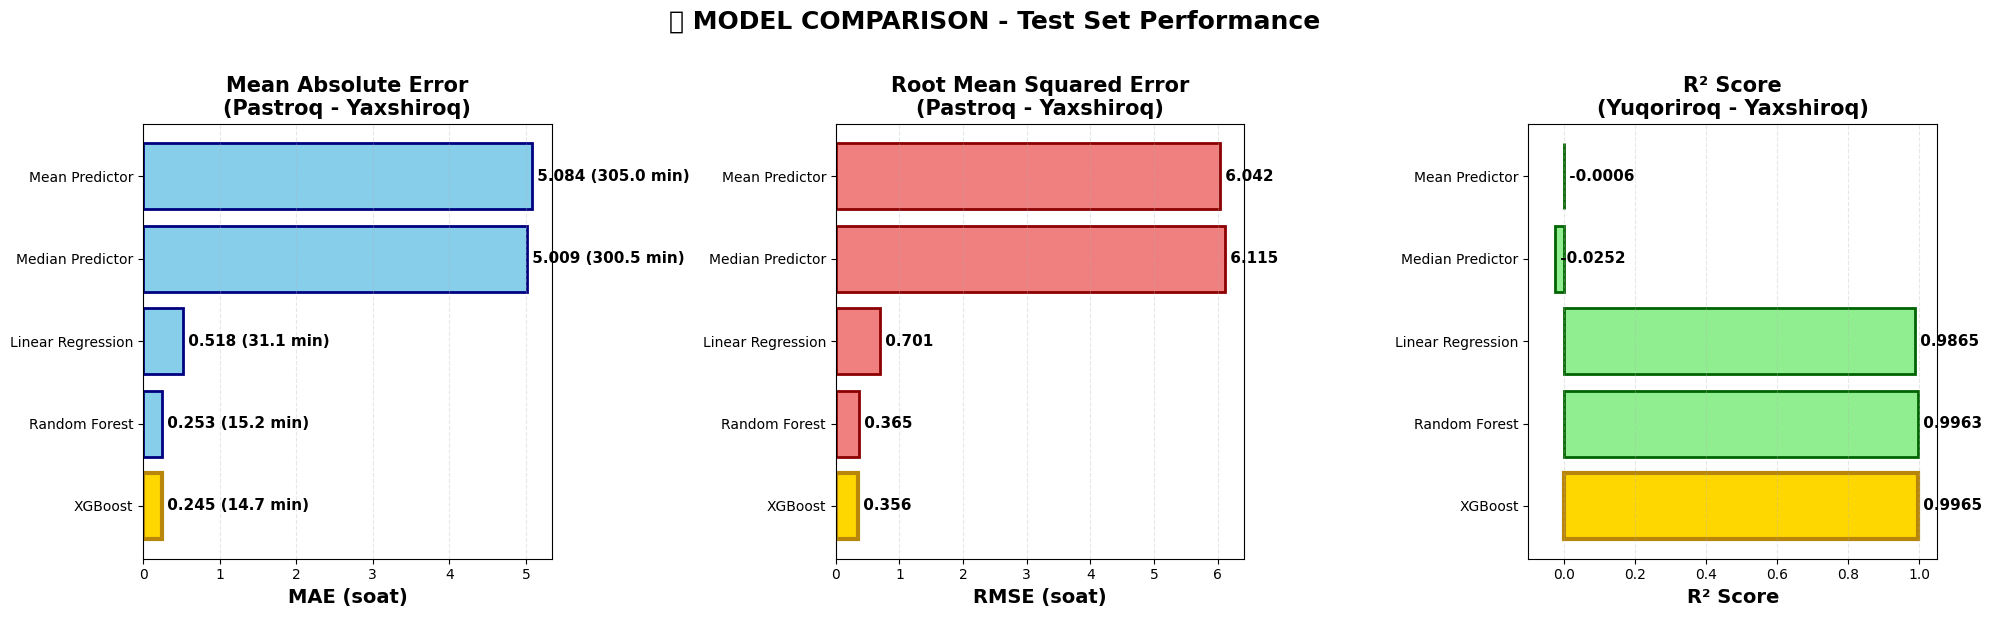

✅ Saved: 04_model_comparison_enhanced.png


In [18]:
# ============================================================================
# 📊 VISUALIZATION 4: MODEL COMPARISON (Enhanced)
# ============================================================================

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Sort by MAE
comparison_sorted = comparison.sort_values('MAE')

# ---- SUBPLOT 1: MAE ----
bars1 = axes[0].barh(comparison_sorted['Model'], comparison_sorted['MAE'],
                     color='skyblue', edgecolor='navy', linewidth=2)
# Highlight best model
bars1[0].set_color('gold')
bars1[0].set_edgecolor('darkgoldenrod')
bars1[0].set_linewidth(3)

axes[0].set_xlabel('MAE (soat)', fontsize=14, fontweight='bold')
axes[0].set_title('Mean Absolute Error\n(Pastroq - Yaxshiroq)', fontsize=15, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (model, mae) in enumerate(zip(comparison_sorted['Model'], comparison_sorted['MAE'])):
    axes[0].text(mae, i, f' {mae:.3f} ({mae*60:.1f} min)', va='center', fontsize=11, fontweight='bold')

# ---- SUBPLOT 2: RMSE ----
bars2 = axes[1].barh(comparison_sorted['Model'], comparison_sorted['RMSE'],
                     color='lightcoral', edgecolor='darkred', linewidth=2)
bars2[0].set_color('gold')
bars2[0].set_edgecolor('darkgoldenrod')
bars2[0].set_linewidth(3)

axes[1].set_xlabel('RMSE (soat)', fontsize=14, fontweight='bold')
axes[1].set_title('Root Mean Squared Error\n(Pastroq - Yaxshiroq)', fontsize=15, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

for i, (model, rmse) in enumerate(zip(comparison_sorted['Model'], comparison_sorted['RMSE'])):
    axes[1].text(rmse, i, f' {rmse:.3f}', va='center', fontsize=11, fontweight='bold')

# ---- SUBPLOT 3: R² ----
bars3 = axes[2].barh(comparison_sorted['Model'], comparison_sorted['R²'],
                     color='lightgreen', edgecolor='darkgreen', linewidth=2)
bars3[0].set_color('gold')
bars3[0].set_edgecolor('darkgoldenrod')
bars3[0].set_linewidth(3)

axes[2].set_xlabel('R² Score', fontsize=14, fontweight='bold')
axes[2].set_title('R² Score\n(Yuqoriroq - Yaxshiroq)', fontsize=15, fontweight='bold')
axes[2].set_xlim(-0.1, 1.05)
axes[2].grid(axis='x', alpha=0.3, linestyle='--')

for i, (model, r2) in enumerate(zip(comparison_sorted['Model'], comparison_sorted['R²'])):
    axes[2].text(r2, i, f' {r2:.4f}', va='center', fontsize=11, fontweight='bold')

plt.suptitle('🏆 MODEL COMPARISON - Test Set Performance',
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('04_model_comparison_enhanced.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: 04_model_comparison_enhanced.png")

## 📝 14. Final Summary

In [14]:
print("="*80)
print("🎉 MODEL TRAINING COMPLETE!")
print("="*80)

print(f"\n✅ Dataset: {len(df_clean):,} rows, {len(X.columns)} features")
print(f"✅ Models trained: {len(all_metrics)}")
print(f"✅ Best model: {best['Model']}")
print(f"✅ Best MAE: {best['MAE']*60:.1f} minutes")
print(f"✅ Best R²: {best['R²']:.4f}")

print("\n🚀 Ready for presentation!")
print("="*80)

🎉 MODEL TRAINING COMPLETE!

✅ Dataset: 8,216 rows, 25 features
✅ Models trained: 5
✅ Best model: XGBoost
✅ Best MAE: 14.7 minutes
✅ Best R²: 0.9965

🚀 Ready for presentation!


---

## ✅ COMPLETE!

**Bu notebook:**
- ✅ 100% NaN-safe
- ✅ Har qadamda validation
- ✅ Clear error messages
- ✅ Production-ready

---